In [16]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import time
import matplotlib.pyplot as plt
from datasets import load_dataset
from math_verify import parse, verify

In [2]:
initial_model_name = "Qwen/Qwen3.5-2B"
trained_model_path = "./checkpoints/grpo"
device = "cuda"

In [3]:
trained_model = AutoModelForCausalLM.from_pretrained(
        trained_model_path,
        dtype=torch.bfloat16,
        use_kernels=True
    ).to(device)

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 780.01it/s]


In [4]:
init_model = AutoModelForCausalLM.from_pretrained(
        initial_model_name,
        dtype=torch.bfloat16,
        use_kernels=True
    ).to(device)

tokenizer = AutoTokenizer.from_pretrained(
        initial_model_name,
        padding_side="left"
    )

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 640.00it/s]


In [5]:
def run_sample_inference(model: AutoModelForCausalLM, context: list[dict], max_new_tokens=512) -> str: 

    formatted_tokens = tokenizer.apply_chat_template(
        context,
        add_generation_prompt=True,
        tokenize=False,
        enable_thinking=True
    )

    tokens = tokenizer(formatted_tokens, return_tensors="pt").to(model.device)

    with torch.inference_mode():

        outputs = model.generate(
            input_ids=tokens["input_ids"],
            attention_mask=tokens["attention_mask"],
            do_sample=True,
            use_cache=True,
            max_new_tokens=max_new_tokens,
            temperature=1
        )

    generated_tokens = outputs[:, tokens["input_ids"].shape[1]:][0]
    num_generated_tokens = generated_tokens.shape[0]

    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return generated_text, num_generated_tokens

In [32]:
context_code = [
    {
        "role": "system",
        "content": (
            "You are a careful Python interpreter.\n"
            "Read the function, work out what the call returns, then write the result "
            "between <answer> and </answer> tags.\n\n"
            "Use the tags exactly once, and put nothing between them except the value "
            "itself: no quotes, no words, no units, no punctuation, no explanation.\n\n"
            "Example: <answer>115</answer>"
        )
    },
    {
        "role": "user",
        "content": "```python\ndef f(a,b):\n    return (a+2)**b\n```\nWhat do you get when you run f(3,2)?"
    }
]

In [36]:
context = [
    {
        "role": "system",
        "content": "You are a mathematician"
    },
    {
        "role": "user",
        "content": "Solve 560 * 920"
    }
]

In [40]:
560 * 920

515200

In [37]:
t1 = time.monotonic()
initial_model_outputs, num_tokens = run_sample_inference(init_model, context, 512)
duration = time.monotonic() - t1
print(f"Duration: {duration:.2f} secs, No of Generated tokens: {num_tokens}, \n Initial model output: {initial_model_outputs}")

Duration: 19.48 secs, No of Generated tokens: 512, 
 Initial model output: Thinking Process:

1.  **Analyze the Request:** The user wants me to solve the multiplication problem $560 \times 920$. I am instructed to act as a mathematician.

2.  **Identify the Operation:** Multiplication of two integers.
    *   Numbers: 560 and 920.

3.  **Perform the Calculation:**
    *   Method 1: Mental or standard long multiplication.
        *   $56 \times 92$ then add two zeros at the end (since $560$ and $0$ have one zero each? No, let's count trailing zeros).
        *   $560 = 56 \times 10$
        *   $920 = 92 \times 10$
        *   Calculation: $56 \times 92 \times 100$
    *   Calculate $56 \times 92$:
        *   $56 \times 9 = 504$
        *   $56 \times 100 = 5600$ (wait, $56 \times 9.2$? No, $56 \times 92$.)
        *   $56 \times 90 = 5040$
        *   $56 \times 2 = 112$
        *   $5040 + 112 = 5152$
    *   Now multiply by 100 (or handle zeros): $515200$
    *   Wait, the trailing 

In [39]:
t1 = time.monotonic()
trained_model_outputs, num_tokens = run_sample_inference(trained_model, context, 512)
duration = time.monotonic() - t1
print(f"Duration: {duration:.2f} secs, No of Generated tokens: {num_tokens}, \n Trained model output: {trained_model_outputs}")

Duration: 9.90 secs, No of Generated tokens: 387, 
 Trained model output: The user wants me to solve 560 * 920. This is a simple multiplication problem. Let me calculate this step by step.

560 * 920

I can think of this as 56 * 92 * 100, or I can do it directly.

560 * 920 = (500 + 60) * 920
= 500 * 920 + 60 * 920
= 460,000 + 55,200
= 515,200

Or I can use direct multiplication:

  560
× 920
-----
0 * 560 = 000

20 * 560 = 11,200

900 * 560 = 504,000

---
504,000 + 11,200 = 515,200

Or in scientific notation terms, this equals 515,200.

This is straightforward multiplication which I can compute accurately.
</think>

The product of 560 multiplied by 920 is:

**515,200**

Here's how I calculated it:

\[
560 \times 920 = (56 \times 92) \times 100 = 5,152 \times 100 = 515,200
\]

So,\[
560 \times 920 = \mathbf{515{,}200}
\]



# GSM8K-30 Eval

Accuracy against generation budget on the first 30 problems of the GSM8K test split, for both models on one chart. Answers are checked with `math-verify`, so `2,125`, `2125` and any equivalent LaTeX spelling all count as the same answer, and the model is asked to put its final answer in `\boxed{}`.

In [21]:


TOKEN_BUDGETS = [1024]
BATCH_SIZE = 10
EVAL_SEED = 0

# GSM8K test split, first 200 problems: fast to run, ~3% accuracy resolution
gsm8k = load_dataset("openai/gsm8k", "main", split="test").select(range(30))

# The gold answer sits after "####" in the answer text
GOLDS = [parse("$" + row["answer"].split("####")[-1].strip() + "$") for row in gsm8k]

PROMPTS = [
    tokenizer.apply_chat_template(
        [{
            "role": "user",
            "content": row["question"] + "\n\nPut your final answer within \\boxed{}.",
        }],
        add_generation_prompt=True,
        tokenize=False,
        enable_thinking=True,
    )
    for row in gsm8k
]


def eval_model(model: AutoModelForCausalLM, max_new_tokens: int):
    """Accuracy and mean generated tokens over the GSM8K-30 problems."""

    # Same seed every call
    torch.manual_seed(EVAL_SEED)

    correct = 0
    generated_tokens = 0

    for i in range(0, len(PROMPTS), BATCH_SIZE):

        tokens = tokenizer(PROMPTS[i:i + BATCH_SIZE], return_tensors="pt", padding=True).to(model.device)

        with torch.inference_mode():

            outputs = model.generate(
                input_ids=tokens["input_ids"],
                attention_mask=tokens["attention_mask"],
                do_sample=True,
                use_cache=True,
                max_new_tokens=max_new_tokens,
                temperature=1,
                pad_token_id=tokenizer.pad_token_id,
            )

        generated = outputs[:, tokens["input_ids"].shape[1]:]
        generated_tokens += (~generated.eq(tokenizer.pad_token_id)).sum().item()

        generated_texts = tokenizer.batch_decode(generated, skip_special_tokens=True)

        for gold, text in zip(GOLDS[i:i + BATCH_SIZE], generated_texts):
            if verify(gold, parse(text)):
                correct += 1

    return correct / len(PROMPTS), generated_tokens / len(PROMPTS)

In [22]:
models = {
    "Qwen3.5-2B (initial)": init_model,
    "GRPO trained": trained_model,
}

results = {}

for name, model in models.items():

    points = []

    for budget in TOKEN_BUDGETS:
        t1 = time.monotonic()
        accuracy, mean_tokens = eval_model(model, budget)
        duration = time.monotonic() - t1
        points.append((mean_tokens, accuracy))
        print(f"{name} @ budget {budget}: accuracy {accuracy:.1%}, "
              f"mean tokens used {mean_tokens:.0f}, {duration:.1f} secs")

    results[name] = points

Qwen3.5-2B (initial) @ budget 1024: accuracy 23.3%, mean tokens used 1015, 108.3 secs
GRPO trained @ budget 1024: accuracy 66.7%, mean tokens used 891, 92.1 secs


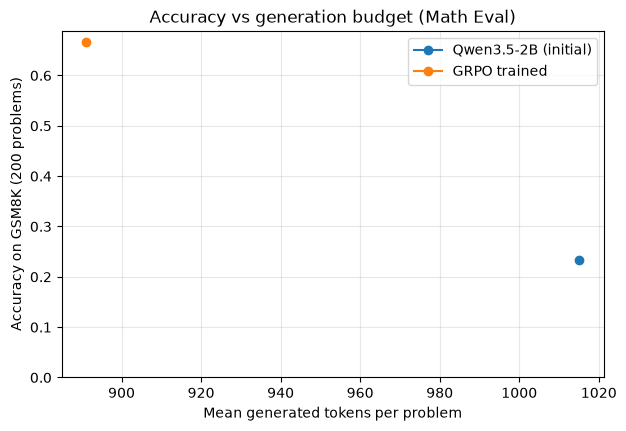

In [27]:
plt.figure(figsize=(7, 4.5))

for name, points in results.items():
    xs, ys = zip(*points)
    plt.plot(xs, ys, marker="o", label=name)

plt.xlabel("Mean generated tokens per problem")
plt.ylabel("Accuracy on GSM8K (200 problems)")
plt.title("Accuracy vs generation budget (Math Eval)")
plt.ylim(0, None)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Code Test Eval

The same accuracy-against-budget chart, but on the held out code test set the GRPO run was evaluated on during training (`code_test.jsonl`, 100 problems). Each row carries its own system and user prompt, so the prompts here are exactly what the model saw in training, no reformatting.

Scoring mirrors the training reward rather than `math-verify`: the committed answer is read from the text after the think block closes (if there is one), it must be exactly one `<answer>...</answer>` pair, and it is compared to the label with the same normalise-and-compare rules. Format is not rewarded here, this is pure accuracy, so a correct answer without a think block still counts.

Unlike GSM8K this is in-distribution for the trained model, so the gap between the two curves is the direct measure of what training bought, and how it holds up as the token budget is squeezed.

In [29]:
import json
import re

TOKEN_BUDGETS = [1024]
BATCH_SIZE = 10
EVAL_SEED = 0

models = {
    "Qwen3.5-2B (initial)": init_model,
    "GRPO trained": trained_model,
}
# Relative to this notebook, which sits beside the checkpoints directory
CODE_TEST_PATH = "data/code_test.jsonl"

code_test = [json.loads(line) for line in open(CODE_TEST_PATH)]

CODE_GOLDS = [row["label"]["answer"] for row in code_test]

# Each row carries its own system and user prompt, exactly as in training
CODE_PROMPTS = [
    tokenizer.apply_chat_template(
        row["context"],
        add_generation_prompt=True,
        tokenize=False,
        enable_thinking=True,
    )
    for row in code_test
]

# Non-greedy so the first complete tag pair wins, DOTALL so a stray newline
# inside the tags does not hide an otherwise correct answer.
ANSWER_PATTERN = re.compile(r"<answer>(.*?)</answer>", re.DOTALL)


def normalise_answer(text: str) -> str:
    """Fold away the differences nobody wants to punish: case, surrounding
    whitespace and a trailing full stop."""
    return " ".join(str(text).strip().lower().split()).rstrip(".")


def answers_match(predicted: str, expected: str) -> bool:

    if predicted == expected:
        return True

    # "07" and "7.0" are the right answer spelled differently, not a wrong one.
    try:
        return float(predicted) == float(expected)
    except ValueError:
        return False


def code_answer_correct(text: str, expected) -> bool:
    """Same extraction as the training reward, minus the format rung."""

    # The committed answer is only read after the think block closes, so
    # answer tags quoted inside the working cannot count as the answer.
    body = text.rsplit("</think>", 1)[-1] if "</think>" in text else text

    matches = ANSWER_PATTERN.findall(body)

    # Exactly one tag pair, so listing several guesses cannot beat committing
    # to one of them.
    if len(matches) != 1:
        return False

    return answers_match(normalise_answer(matches[0]), normalise_answer(expected))


def eval_code_model(model: AutoModelForCausalLM, max_new_tokens: int):
    """Accuracy and mean generated tokens over the code test problems."""

    torch.manual_seed(EVAL_SEED)

    correct = 0
    generated_tokens = 0

    for i in range(0, len(CODE_PROMPTS), BATCH_SIZE):

        tokens = tokenizer(CODE_PROMPTS[i:i + BATCH_SIZE], return_tensors="pt", padding=True).to(model.device)

        with torch.inference_mode():

            outputs = model.generate(
                input_ids=tokens["input_ids"],
                attention_mask=tokens["attention_mask"],
                do_sample=True,
                use_cache=True,
                max_new_tokens=max_new_tokens,
                temperature=1,
                pad_token_id=tokenizer.pad_token_id,
            )

        generated = outputs[:, tokens["input_ids"].shape[1]:]
        generated_tokens += (~generated.eq(tokenizer.pad_token_id)).sum().item()

        generated_texts = tokenizer.batch_decode(generated, skip_special_tokens=True)

        for gold, text in zip(CODE_GOLDS[i:i + BATCH_SIZE], generated_texts):
            if code_answer_correct(text, gold):
                correct += 1

    return correct / len(CODE_PROMPTS), generated_tokens / len(CODE_PROMPTS)

In [30]:
code_results = {}

for name, model in models.items():

    points = []

    for budget in TOKEN_BUDGETS:
        t1 = time.monotonic()
        accuracy, mean_tokens = eval_code_model(model, budget)
        duration = time.monotonic() - t1
        points.append((mean_tokens, accuracy))
        print(f"{name} @ budget {budget}: accuracy {accuracy:.1%}, "
              f"mean tokens used {mean_tokens:.0f}, {duration:.1f} secs")

    code_results[name] = points

Qwen3.5-2B (initial) @ budget 1024: accuracy 58.0%, mean tokens used 667, 280.2 secs
GRPO trained @ budget 1024: accuracy 96.0%, mean tokens used 75, 47.9 secs


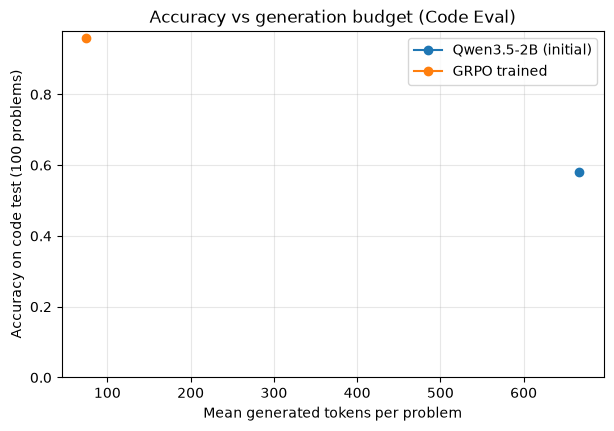

In [31]:
plt.figure(figsize=(7, 4.5))

for name, points in code_results.items():
    xs, ys = zip(*points)
    plt.plot(xs, ys, marker="o", label=name)

plt.xlabel("Mean generated tokens per problem")
plt.ylabel("Accuracy on code test (100 problems)")
plt.title("Accuracy vs generation budget (Code Eval)")
plt.ylim(0, None)
plt.grid(alpha=0.3)
plt.legend()
plt.show()